<a href="https://colab.research.google.com/github/Loki-33/AEStuffs/blob/main/VAE_Disentanglement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
import numpy as np
import urllib.request

In [ ]:
url = "https://github.com/deepmind/dsprites-dataset/raw/master/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz"
urllib.request.urlretrieve(url, "dsprites.npz")

('dsprites.npz', <http.client.HTTPMessage at 0x7a75d1001130>)

In [ ]:
dataset = np.load('dsprites.npz', allow_pickle=True)

In [ ]:
dataset.files

['metadata', 'imgs', 'latents_classes', 'latents_values']

In [ ]:
images=dataset['imgs']

In [ ]:
import matplotlib.pyplot as plt

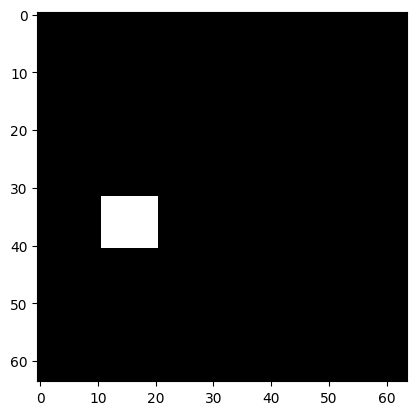

In [ ]:
plt.imshow(images[20], cmap='gray')

In [ ]:
images[0].shape

(64, 64)

In [ ]:
train_data=torch.tensor(images[:100000], dtype=torch.float32)

In [ ]:
class VAE(nn.Module):
  def __init__(self, input_dim, latent_dim):
    super(VAE, self).__init__()
    self.encoder=nn.Sequential(
        nn.Linear(input_dim, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU()
    )
    self.decoder=nn.Sequential(
        nn.Linear(latent_dim, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, input_dim),
        nn.Sigmoid()
    )
    self.mu = nn.Linear(128, latent_dim)
    self.log_var = nn.Linear(128, latent_dim)

  def reparameterize(self, mu, log_var):
    std = torch.exp(0.5*log_var)
    eps = torch.randn_like(std)
    return mu + eps*std

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.encoder(x)
    mu = self.mu(x)
    log_var = self.log_var(x)
    z = self.reparameterize(mu, log_var)
    x_hat = self.decoder(z)

    return x_hat, mu, log_var

In [ ]:
input_dim=64*64
latent_dim=20

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

In [ ]:
import torch.nn.functional as F

In [ ]:
def vae_loss(x_hat, x, mu, log_var, beta=1.0):
  x = x.view(x.size(0), -1)
  recon_loss = F.mse_loss(x_hat, x, reduction='sum')/x.size(0)
  kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())/x.size(0)
  total_loss= recon_loss + beta * kl_loss
  return total_loss, recon_loss, kl_loss

In [ ]:
def train():
  betas = [0.5, 1, 4, 7, 10, 15]
  for b in betas:
    model = VAE(input_dim, latent_dim=20)
    model.to('cuda')
    optimizer=optim.AdamW(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(20):
      epoch_loss = 0
      tkl_loss=0
      trecon_loss=0
      for batch in train_loader:
        batch = batch.to('cuda')
        x_hat, mu, log_var = model(batch)
        loss, recon_loss, kl_loss = vae_loss(x_hat, batch, mu, log_var, beta=b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        tkl_loss += kl_loss.item()
        trecon_loss += recon_loss.item()
      print(f"Beta {b}, Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader):.2f}, KL LOSS: {tkl_loss/len(train_loader):.2f}, RECON LOSS: {trecon_loss/len(train_loader):.2f}")
    torch.save(model.state_dict(), f'vae_beta_{b}.pth')

In [ ]:
train()

Beta 0.5, Epoch 1, Loss: 49.44, KL LOSS: 11.98, RECON LOSS: 43.45
Beta 0.5, Epoch 2, Loss: 25.49, KL LOSS: 11.34, RECON LOSS: 19.82
Beta 0.5, Epoch 3, Loss: 24.13, KL LOSS: 11.20, RECON LOSS: 18.53
Beta 0.5, Epoch 4, Loss: 23.59, KL LOSS: 11.09, RECON LOSS: 18.04
Beta 0.5, Epoch 5, Loss: 23.24, KL LOSS: 11.04, RECON LOSS: 17.72
Beta 0.5, Epoch 6, Loss: 22.93, KL LOSS: 11.03, RECON LOSS: 17.42
Beta 0.5, Epoch 7, Loss: 22.63, KL LOSS: 11.07, RECON LOSS: 17.10
Beta 0.5, Epoch 8, Loss: 22.35, KL LOSS: 11.13, RECON LOSS: 16.79
Beta 0.5, Epoch 9, Loss: 22.10, KL LOSS: 11.22, RECON LOSS: 16.50
Beta 0.5, Epoch 10, Loss: 21.89, KL LOSS: 11.30, RECON LOSS: 16.24
Beta 0.5, Epoch 11, Loss: 21.68, KL LOSS: 11.34, RECON LOSS: 16.01
Beta 0.5, Epoch 12, Loss: 21.51, KL LOSS: 11.41, RECON LOSS: 15.81
Beta 0.5, Epoch 13, Loss: 21.33, KL LOSS: 11.44, RECON LOSS: 15.60
Beta 0.5, Epoch 14, Loss: 21.18, KL LOSS: 11.47, RECON LOSS: 15.44
Beta 0.5, Epoch 15, Loss: 21.08, KL LOSS: 11.51, RECON LOSS: 15.33
Beta

In [ ]:
models_state = {
    'beta_0.5': 'vae_beta_0.5.pth',
    'beta_1': 'vae_beta_1.pth',
    'beta_4': 'vae_beta_4.pth',
    'beta_7': 'vae_beta_7.pth',
    'beta_10': 'vae_beta_10.pth',
    'beta_15': 'vae_beta_15.pth'
}

In [ ]:
def latent_traversal(model, latent_dim=20, n_samples=10, range_val=3):
    model.eval()
    fig, axes = plt.subplots(latent_dim, n_samples, figsize=(n_samples*1.5, latent_dim*1.5))

    with torch.no_grad():
        for i in range(latent_dim):
            # Create base latent vector (all zeros)
            base_z = torch.zeros(1, latent_dim)

            # Vary dimension i
            values = torch.linspace(-range_val, range_val, n_samples)
            for j, val in enumerate(values):
                z = base_z.clone()
                z[0, i] = val

                # Decode
                x_hat = model.decoder(z)
                img = x_hat.view(64, 64).cpu().numpy()

                axes[i, j].imshow(img, cmap='gray')
                axes[i, j].axis('off')

            axes[i, 0].set_ylabel(f'Dim {i}', rotation=0, labelpad=30)

    plt.tight_layout()
    plt.savefig('latent_traversal.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
model = VAE(input_dim, latent_dim=20)


beta_0.5


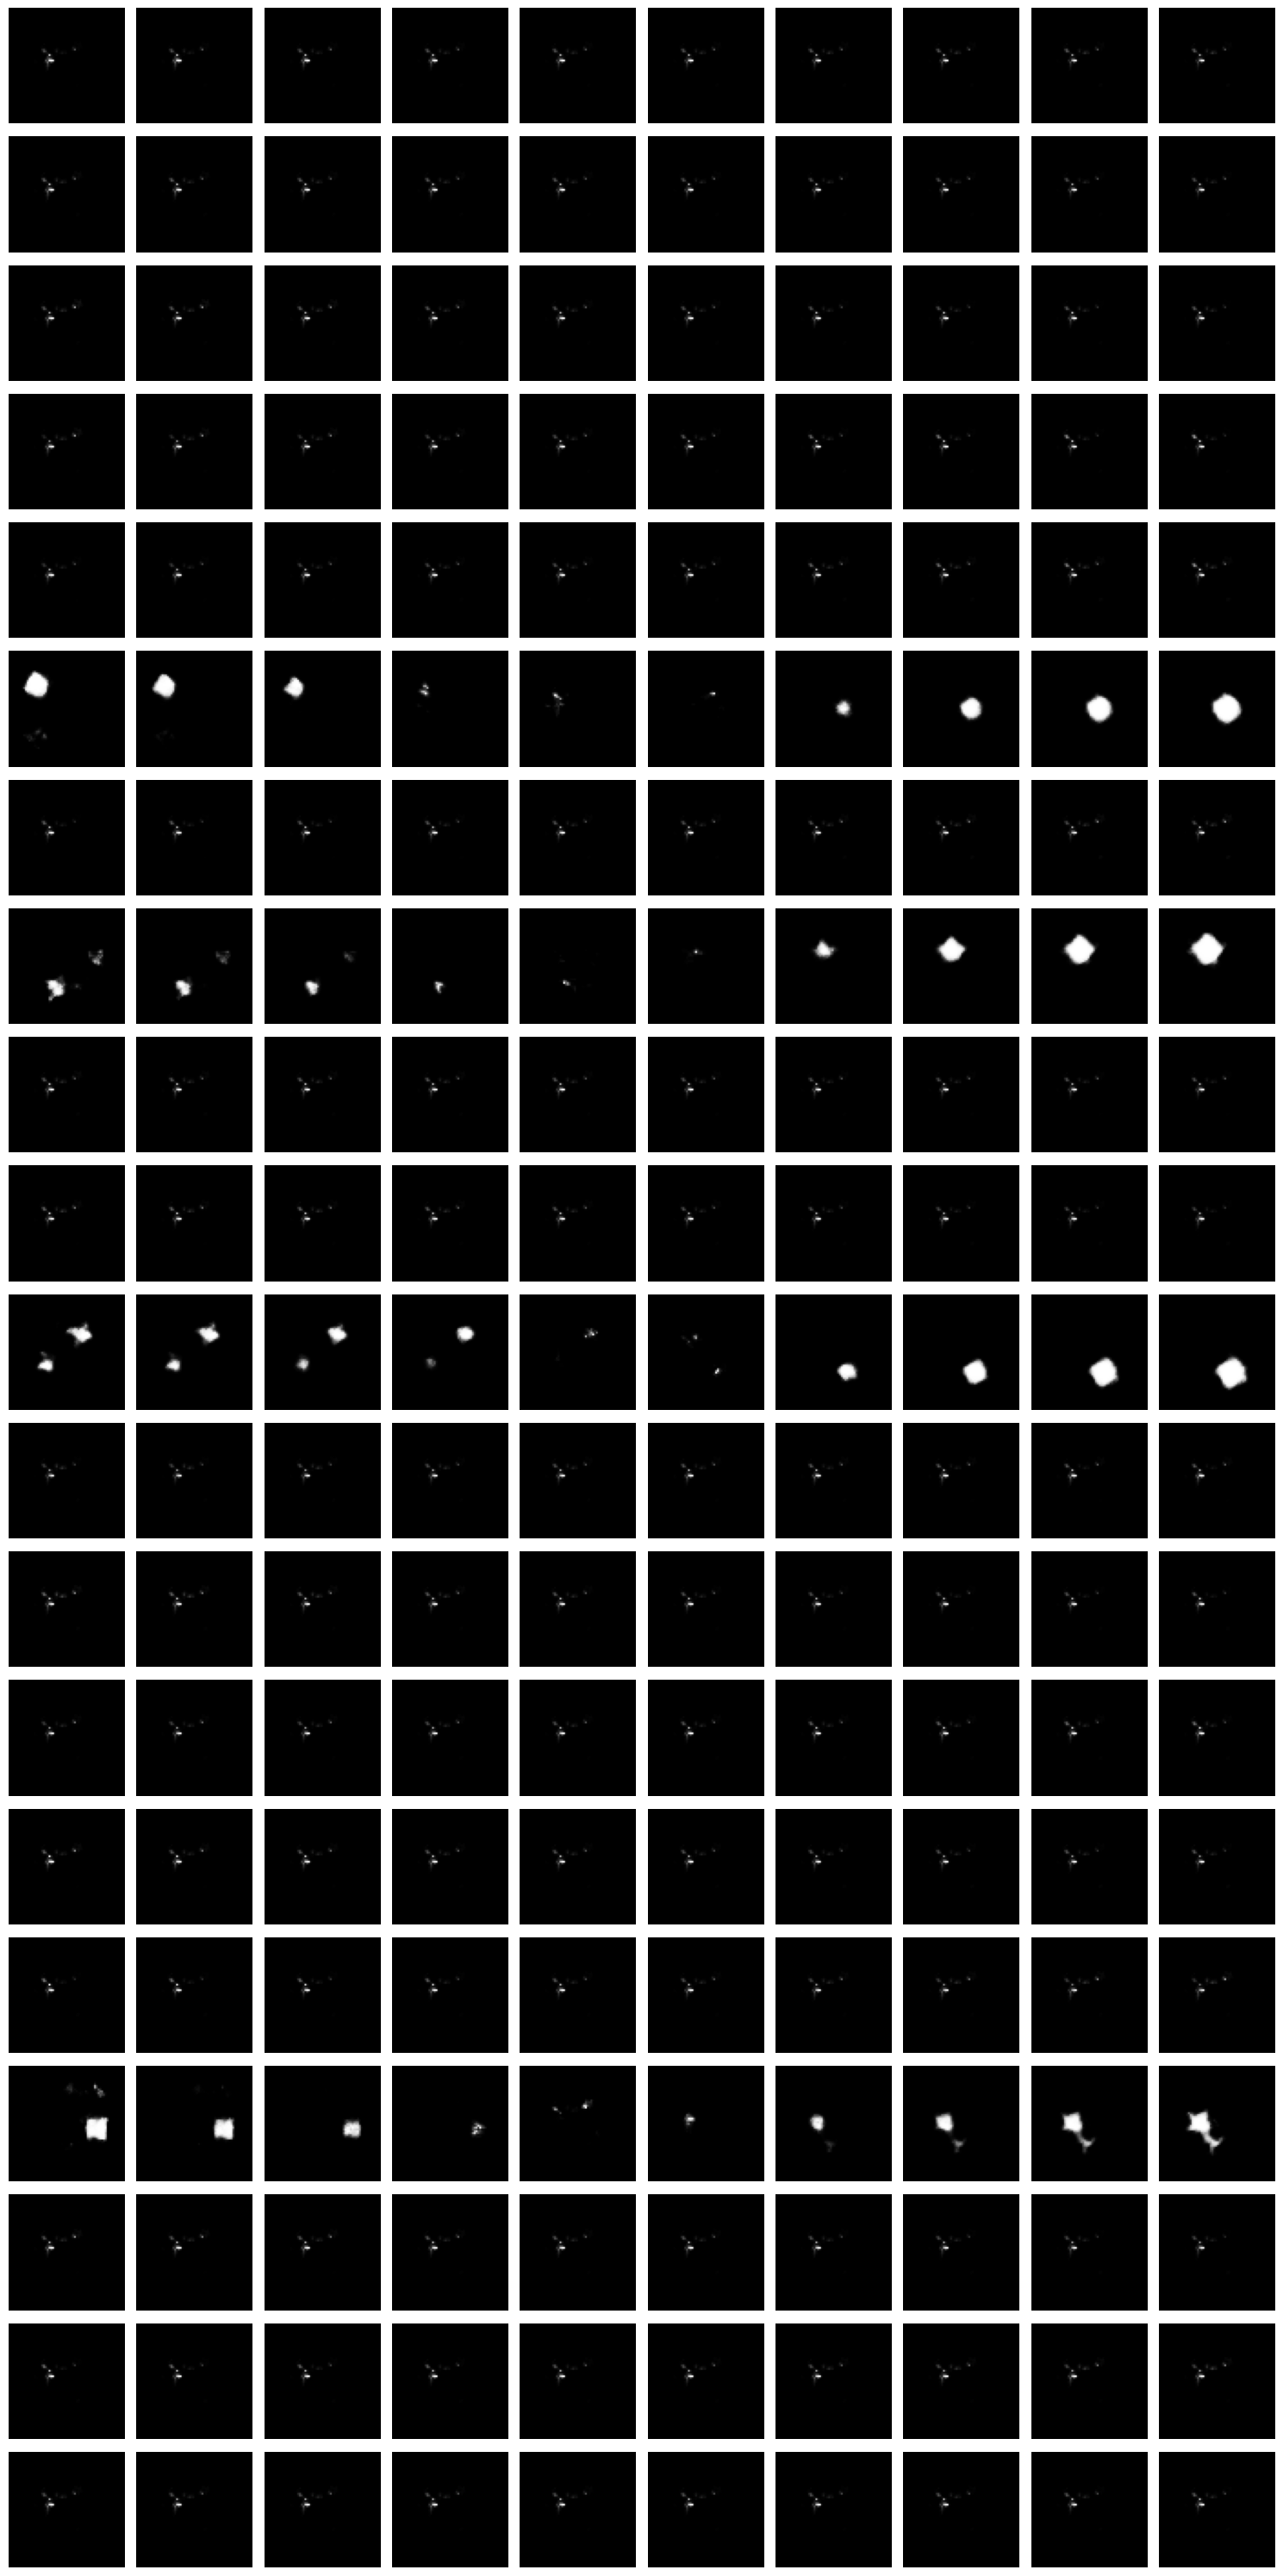


beta_1


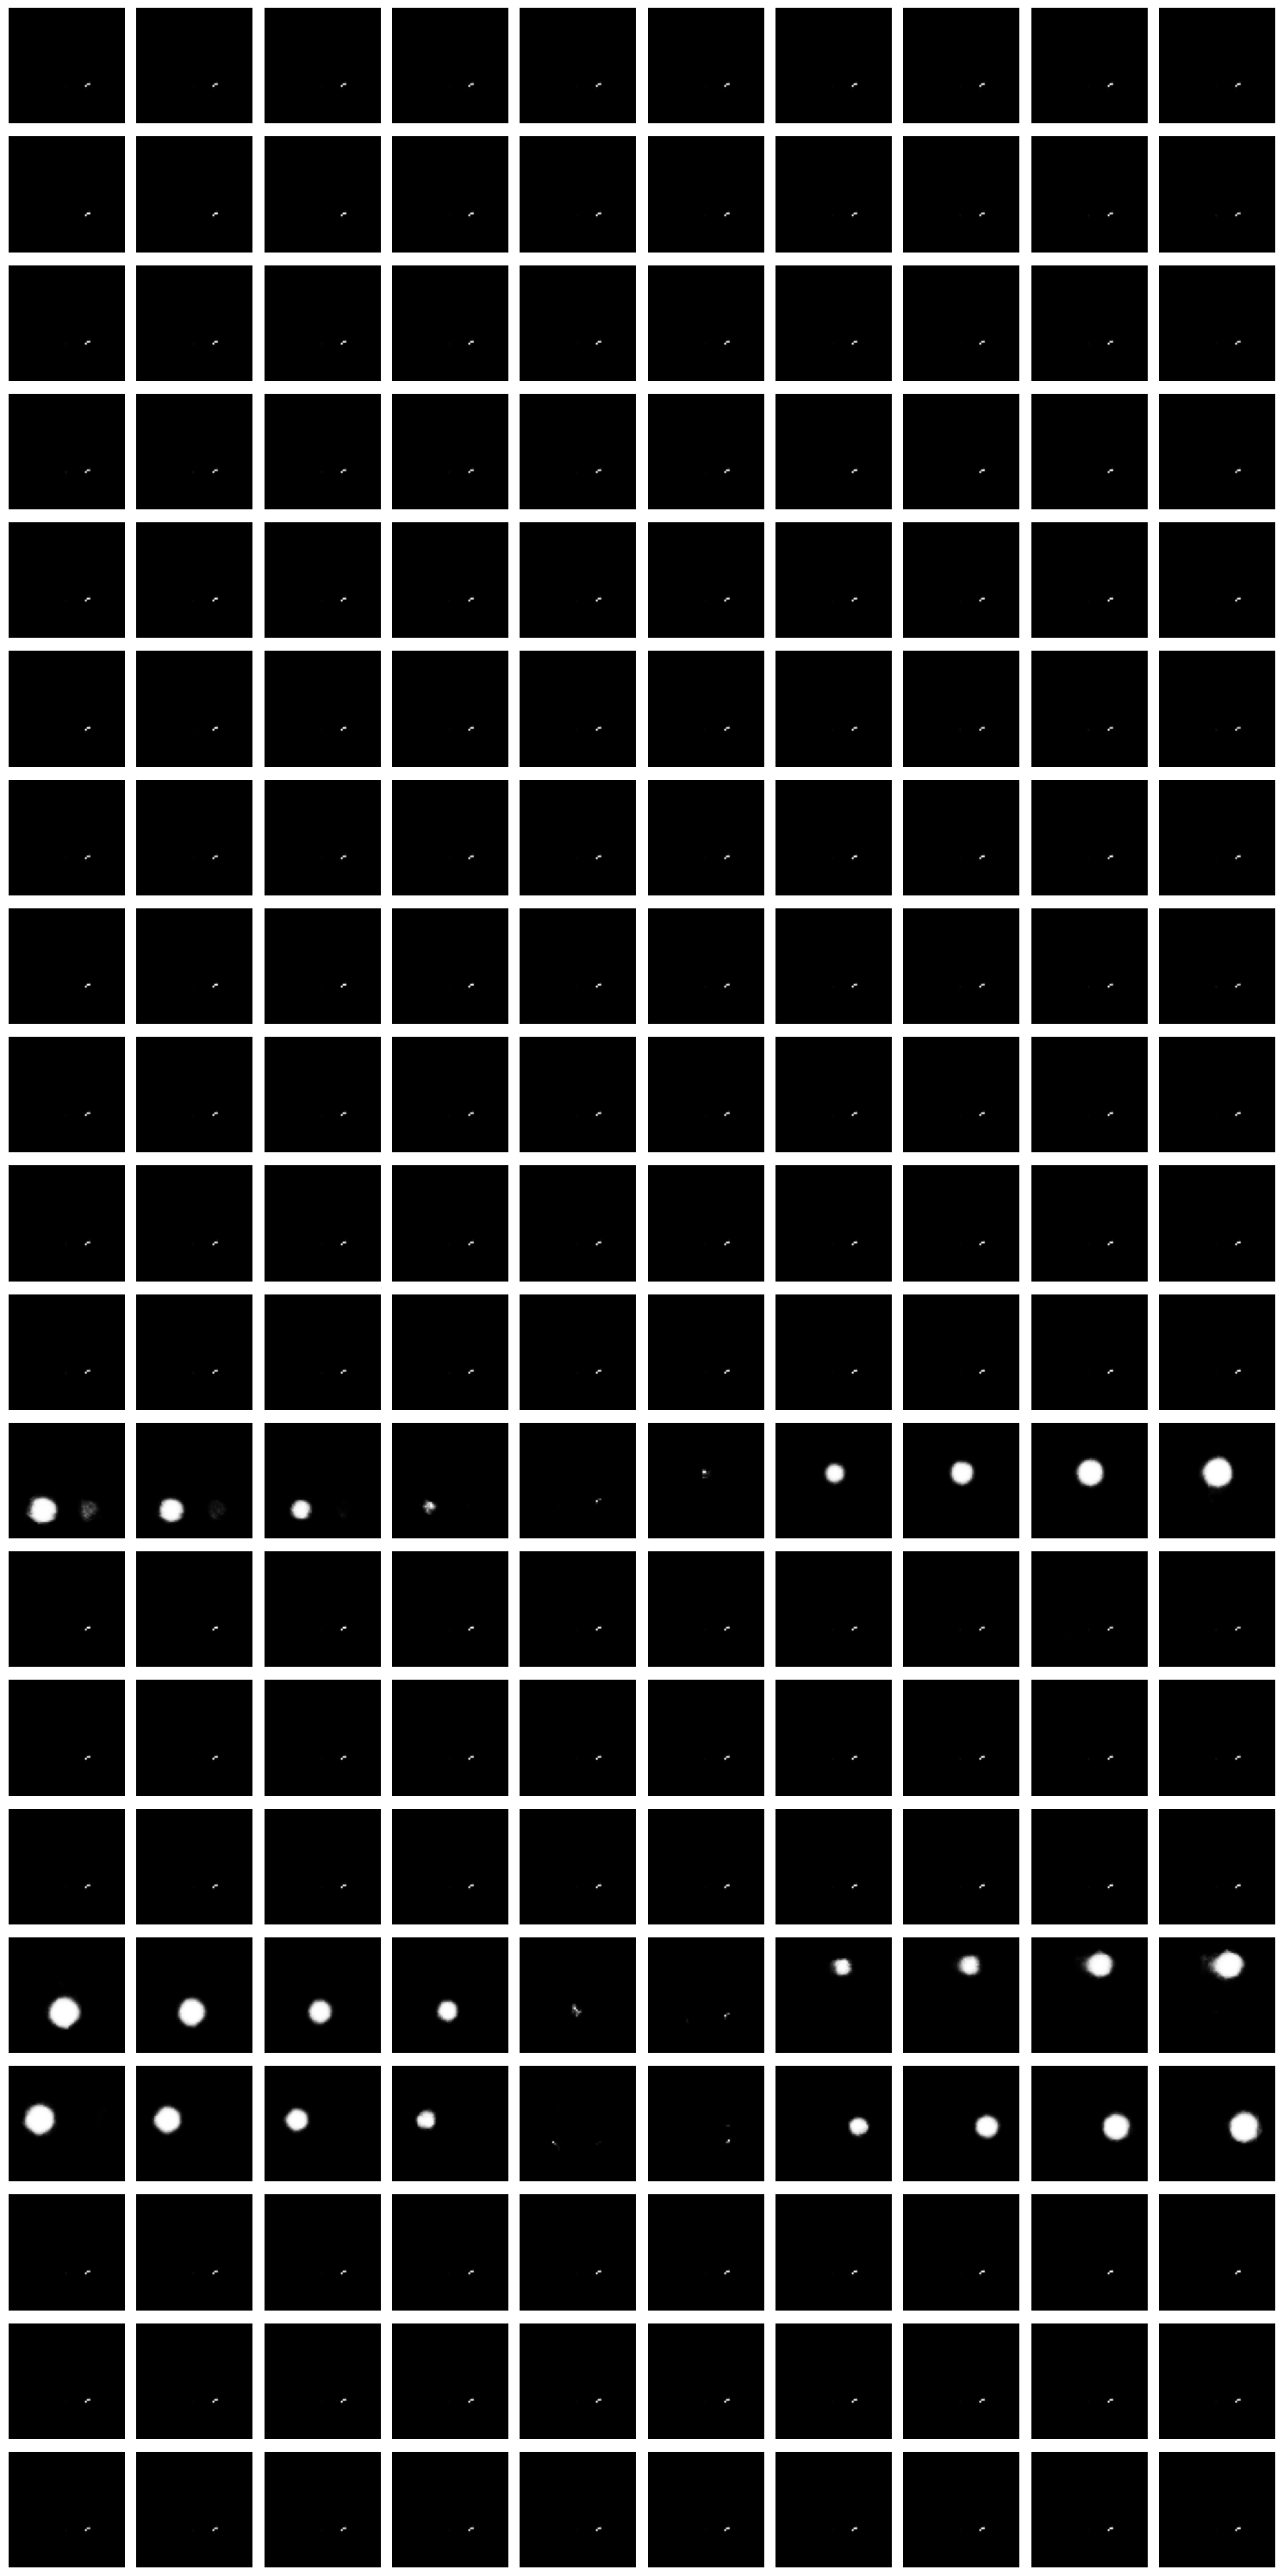


beta_4


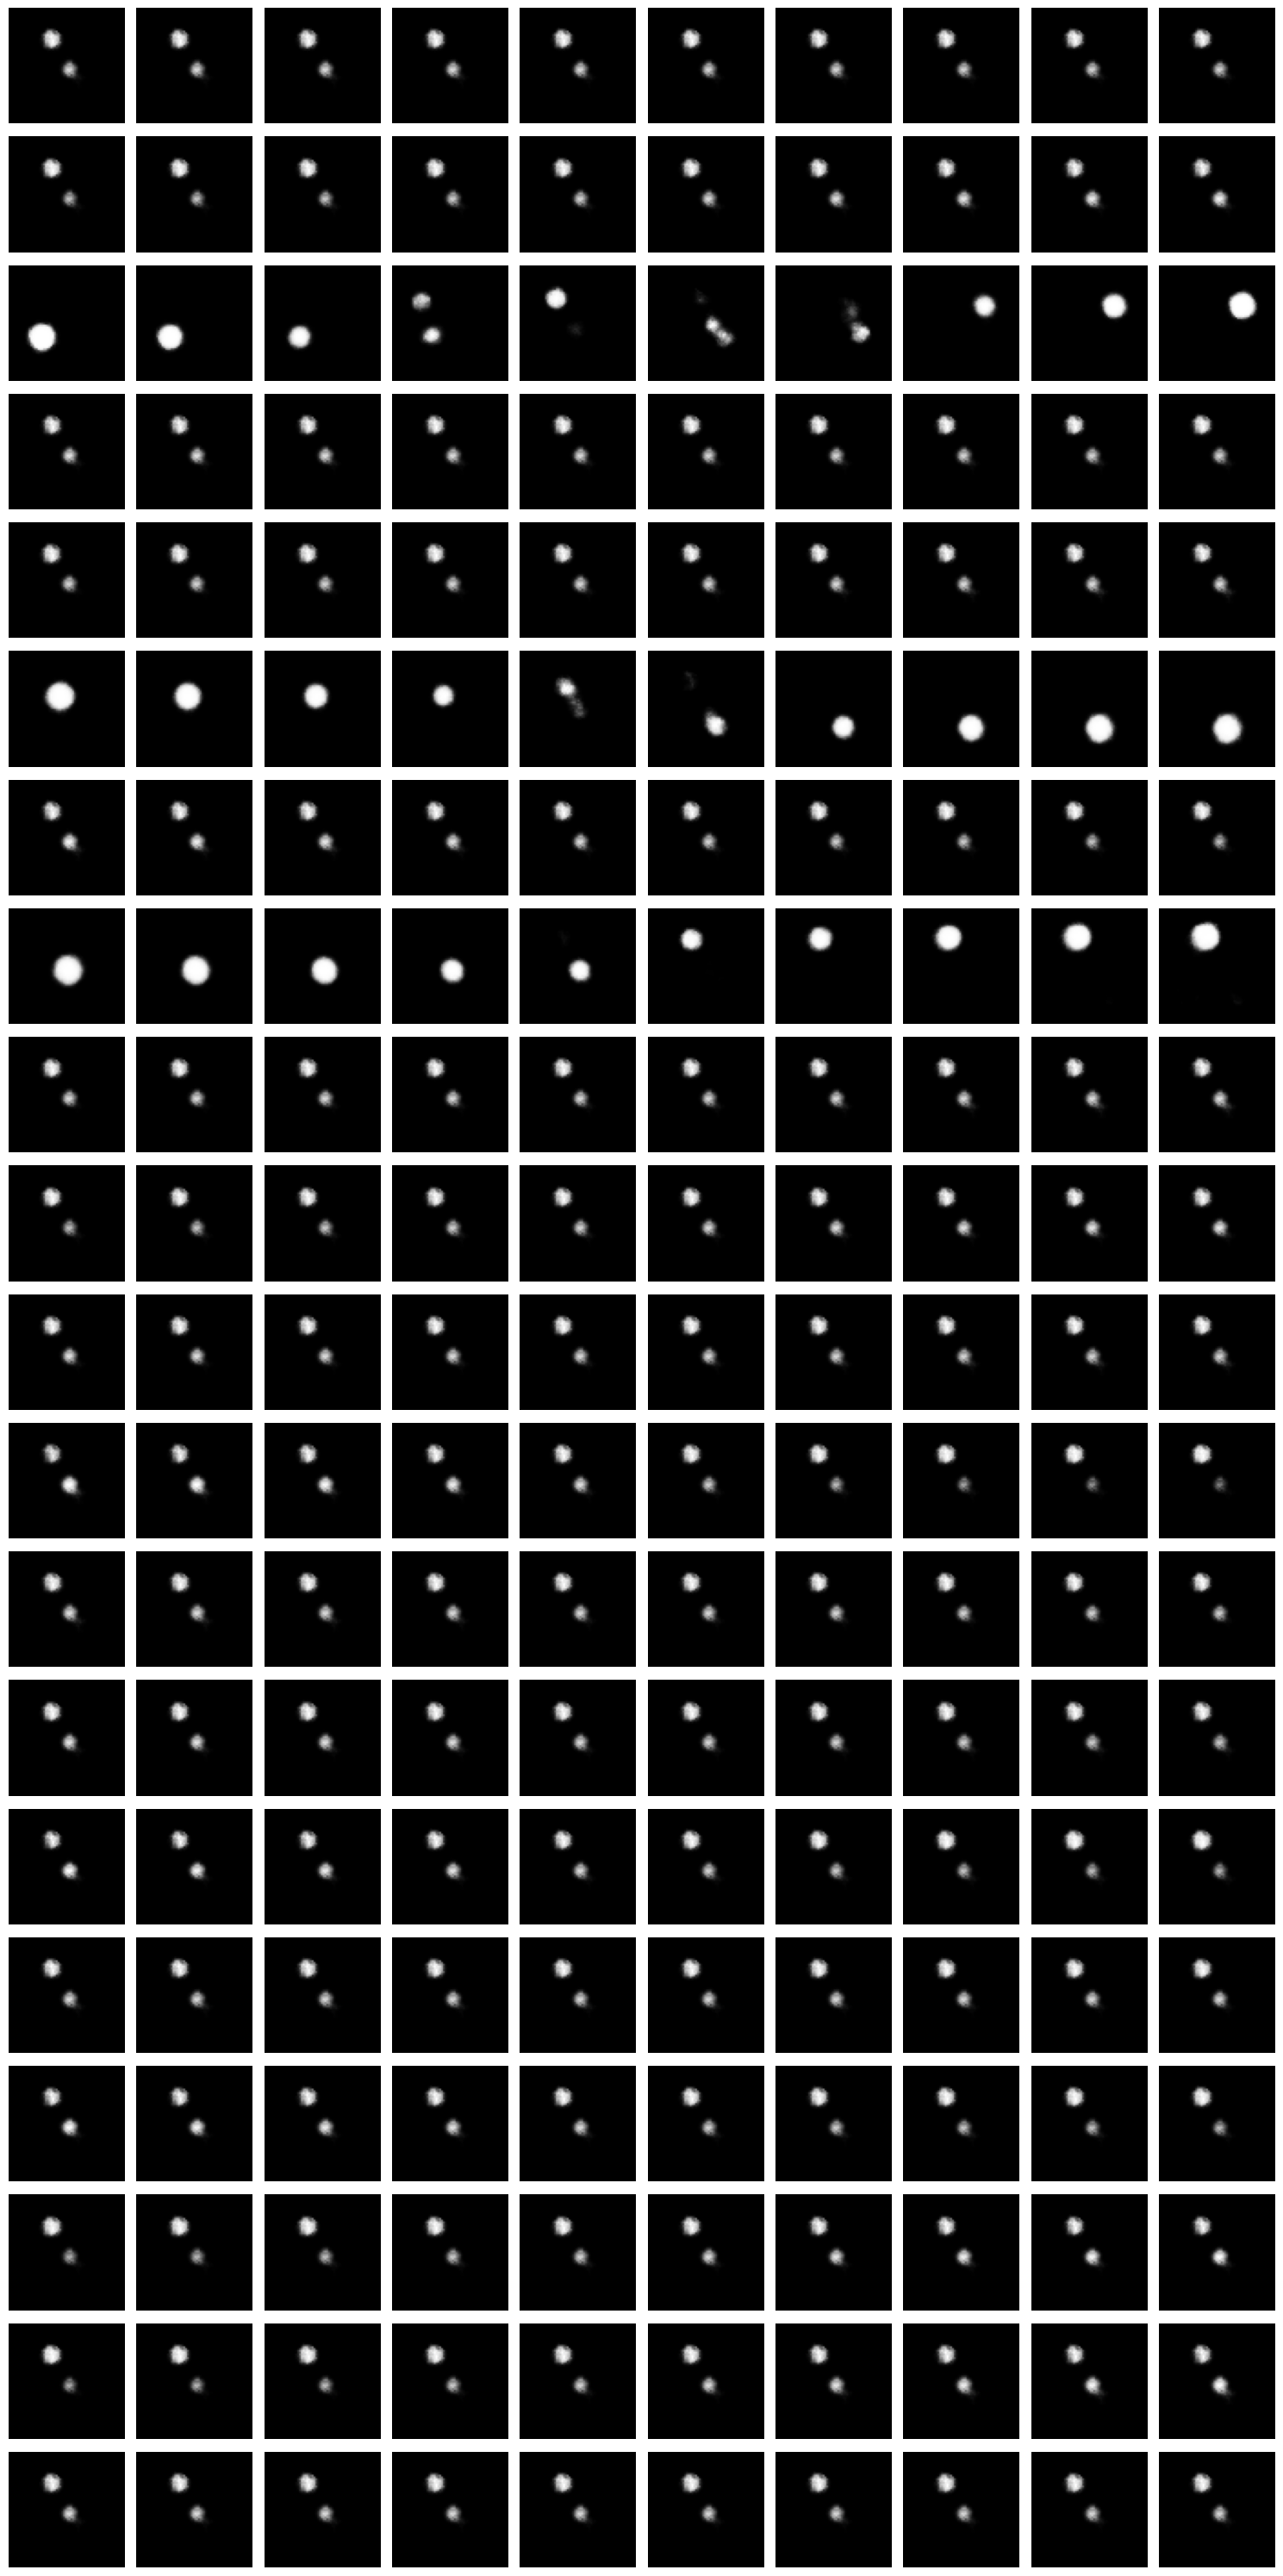


beta_7


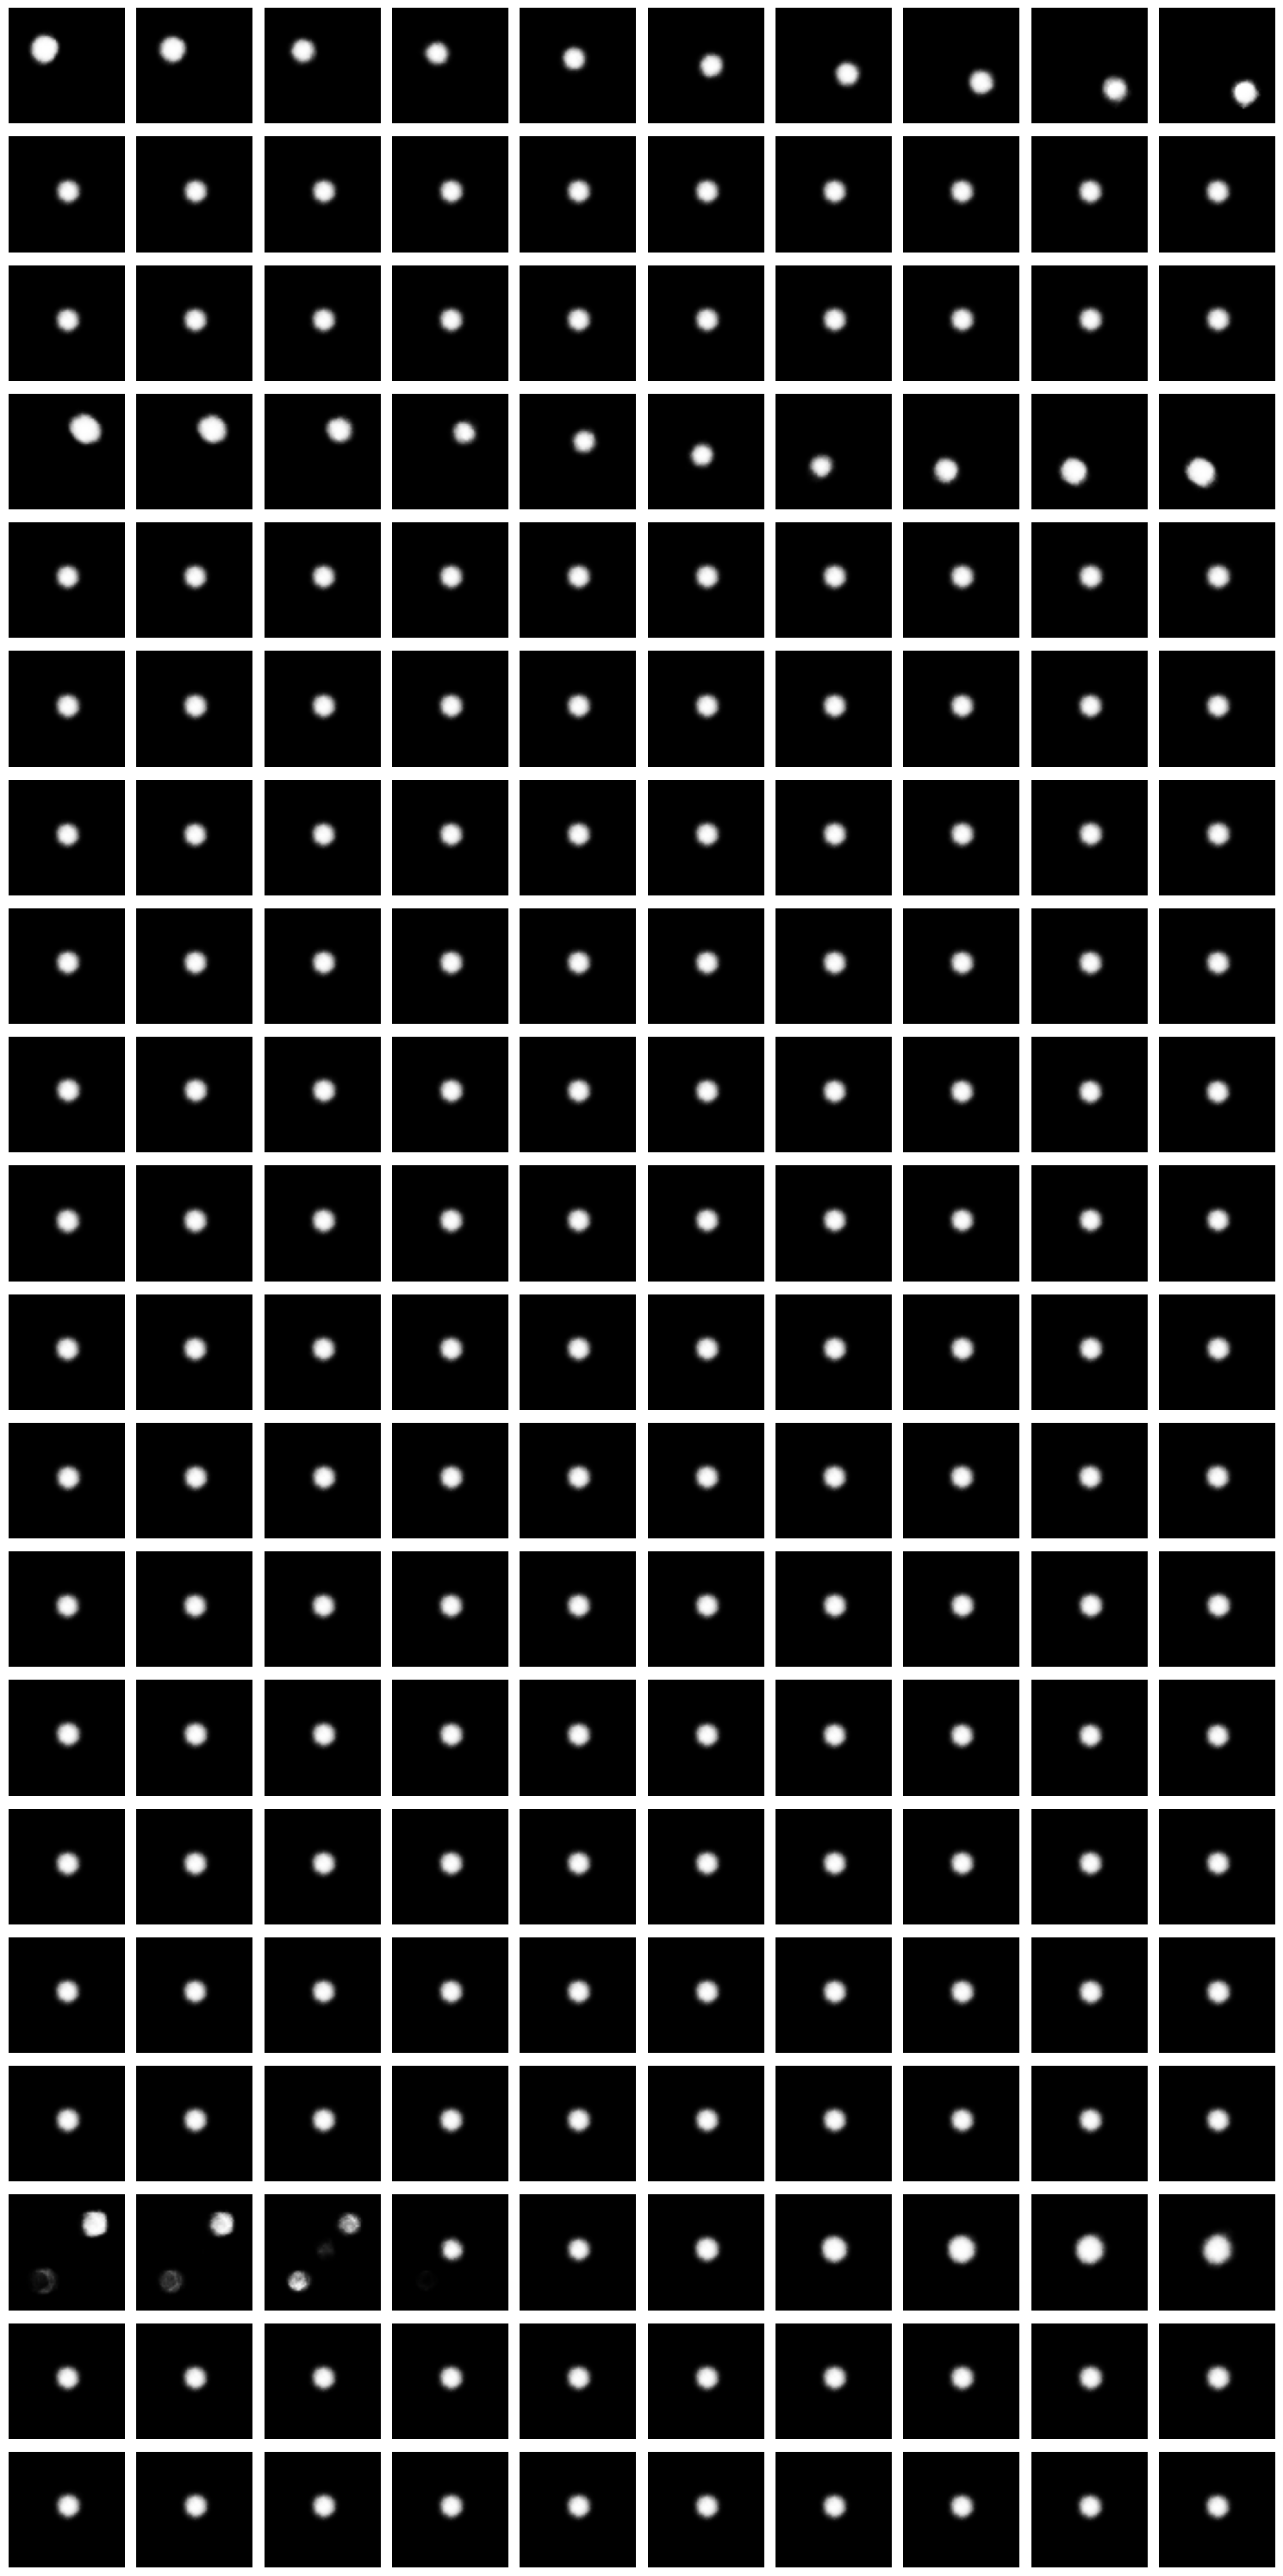


beta_10


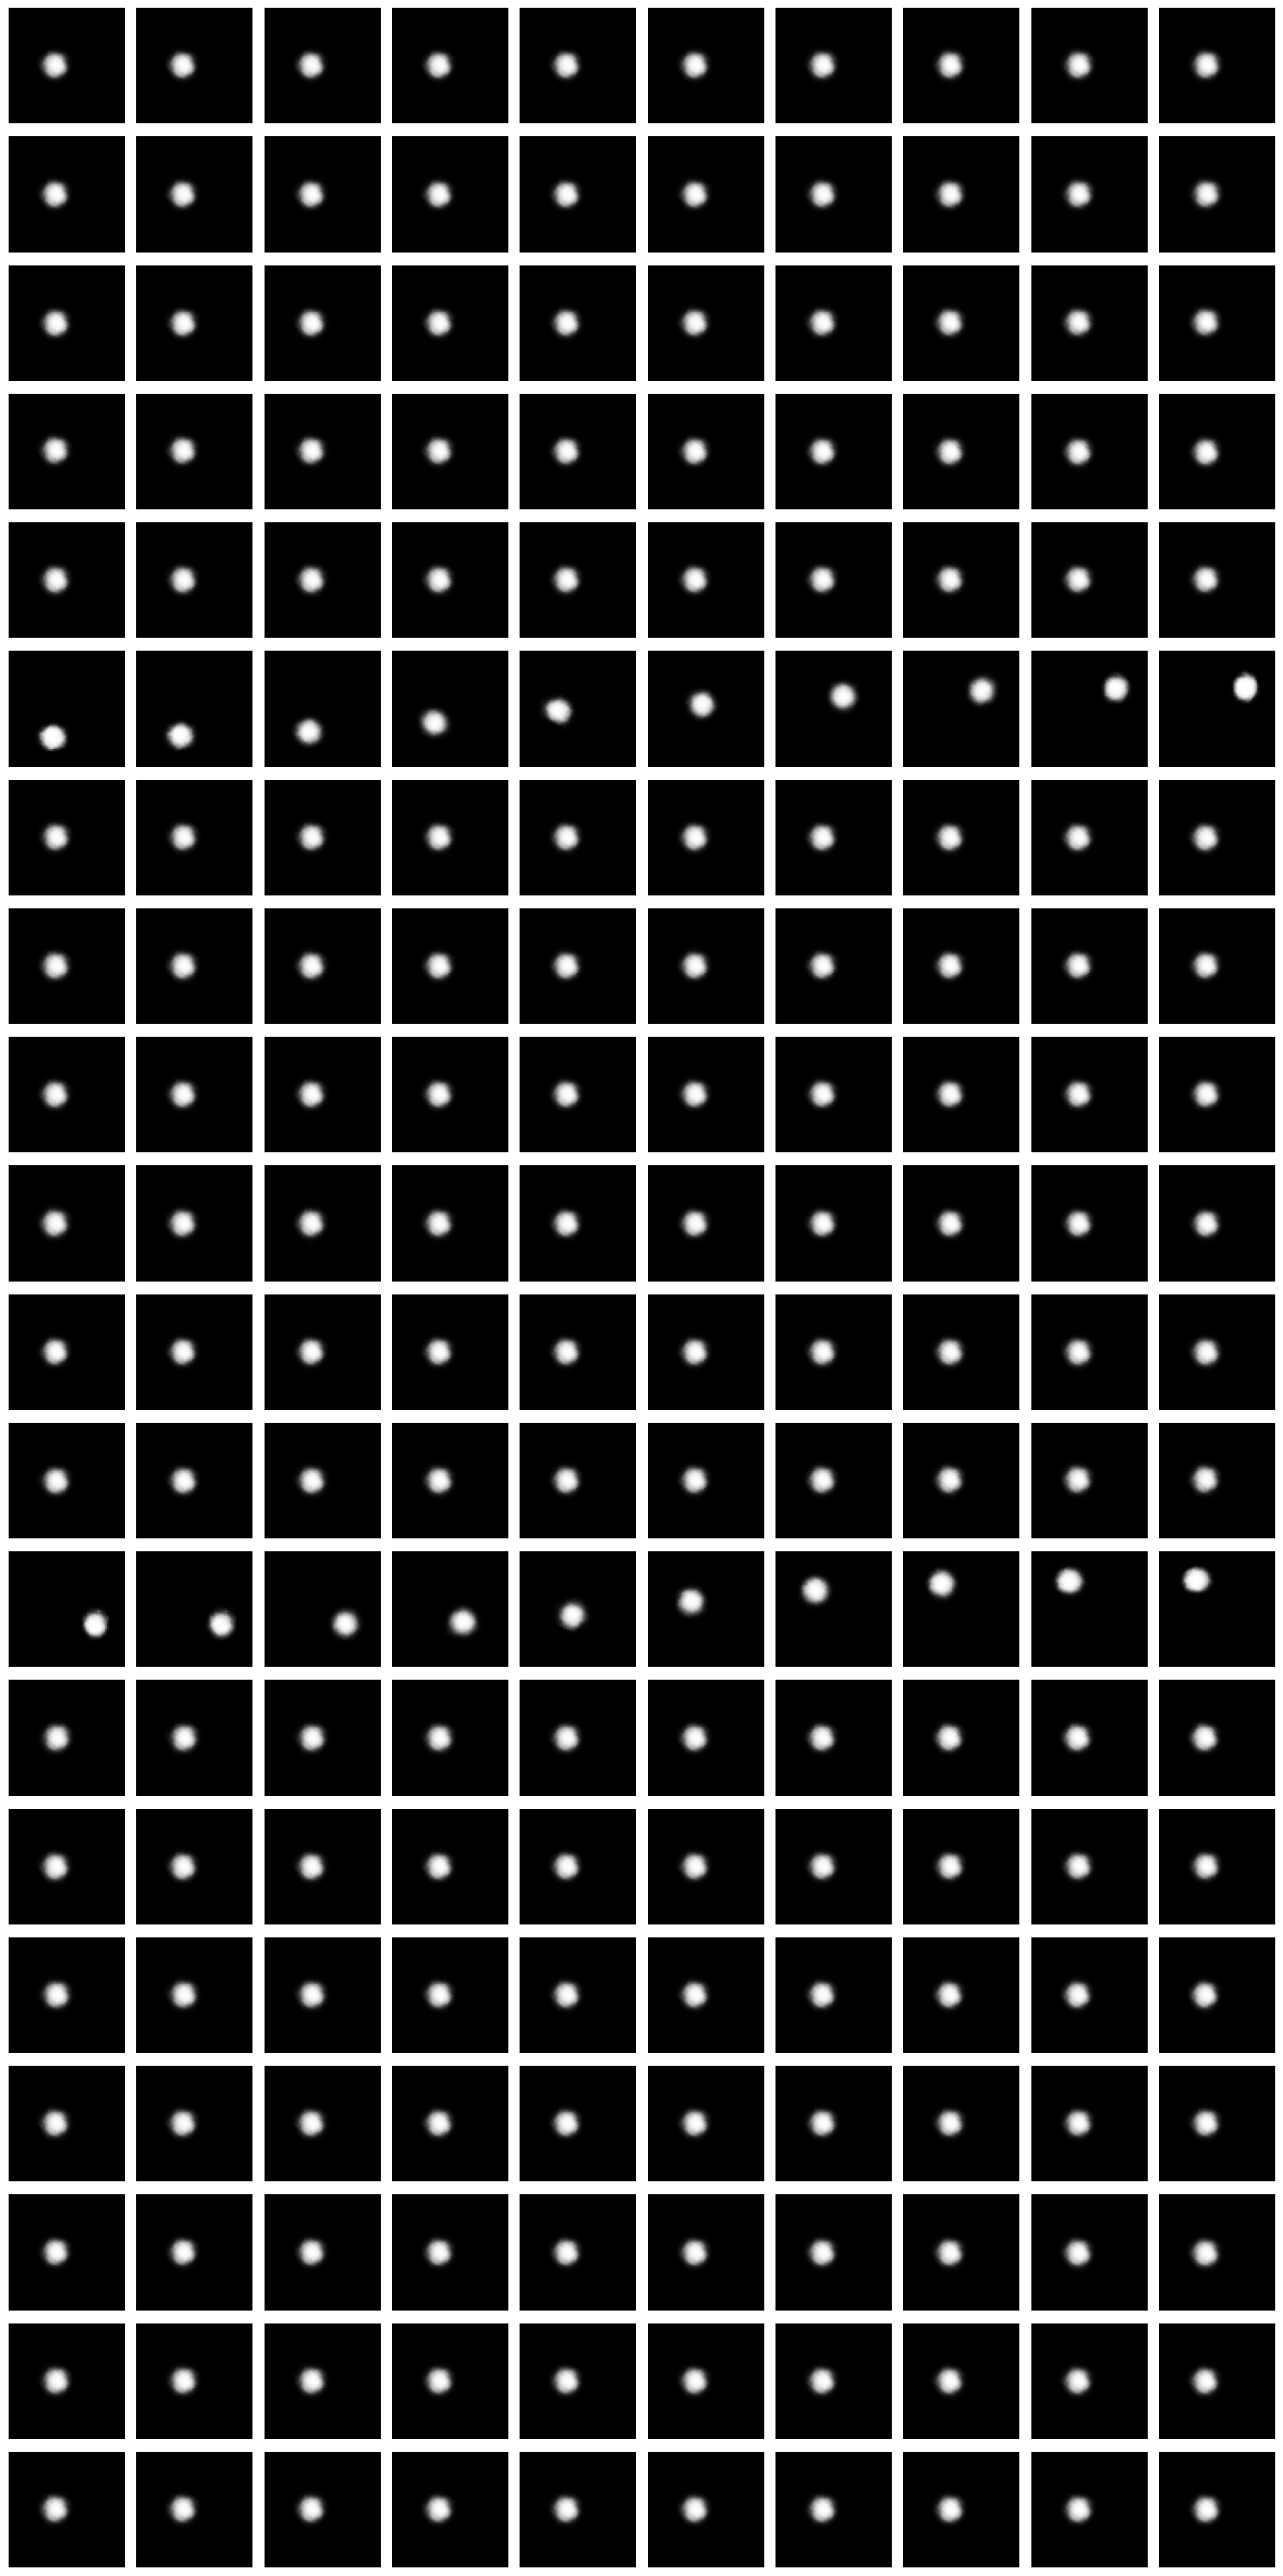


beta_15


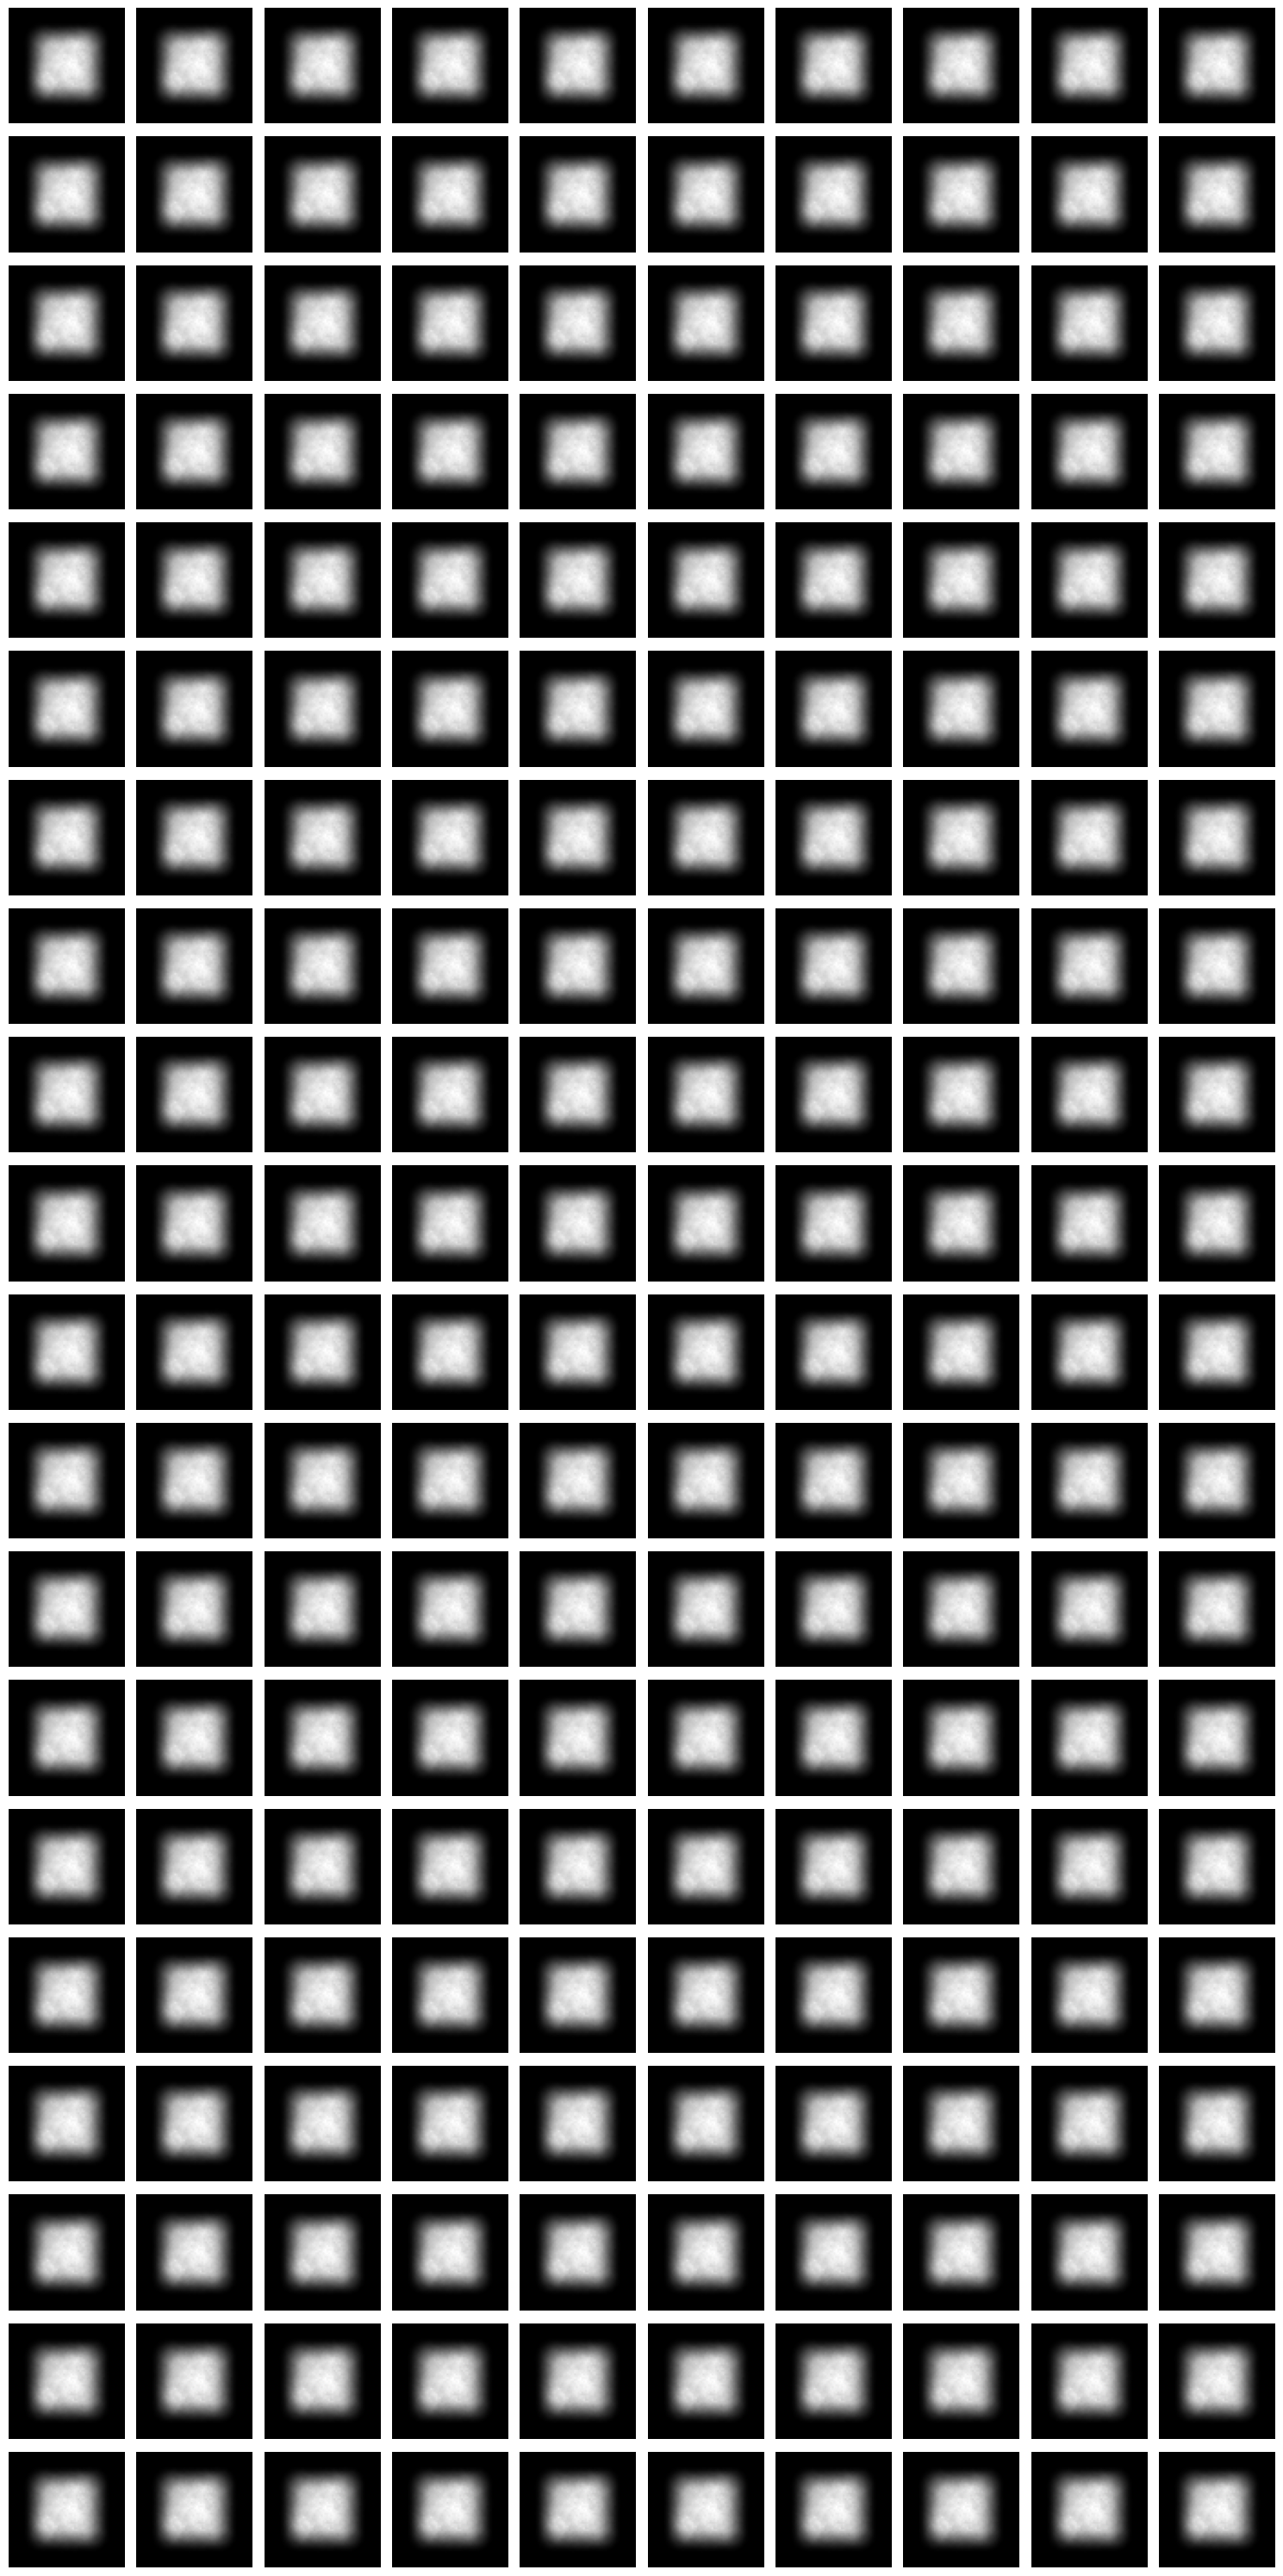

In [ ]:
for beta_name, path in models_state.items():
    print(f"\n{beta_name}")
    model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))
    latent_traversal(model)

In [ ]:
def analyze_latent_statistics(model, data_loader):
    model.eval()
    all_mus = []

    with torch.no_grad():
        for batch in data_loader:
            x = batch.view(batch.size(0), -1)
            x = model.encoder(x)
            mu = model.mu(x) # shape (32, 20)
            all_mus.append(mu.cpu())

    all_mus = torch.cat(all_mus, dim=0) # shape (100000, 20)

    # Compute variance and correlation
    variances = all_mus.var(dim=0)
    corr_matrix = torch.corrcoef(all_mus.T)
    return variances, corr_matrix

In [ ]:
import numpy


beta_0.5
Active dimensions (var > 0.1): 4
Mean abs correlation: 0.255


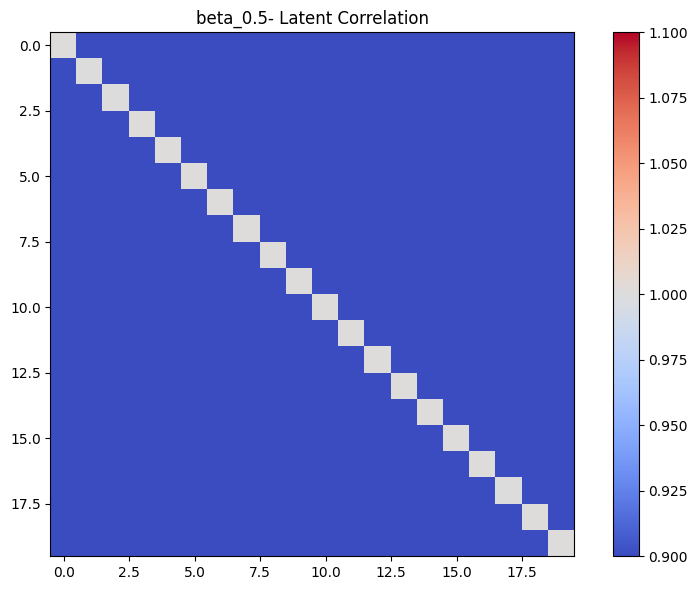


beta_1
Active dimensions (var > 0.1): 3
Mean abs correlation: 0.285


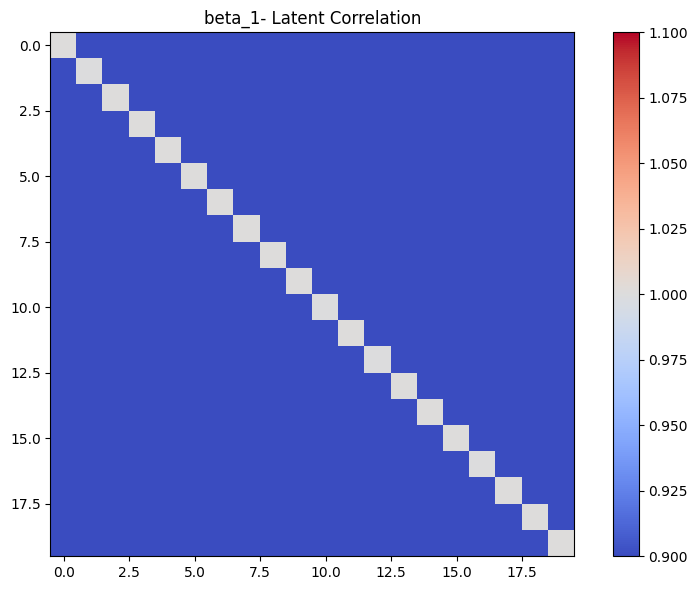


beta_4
Active dimensions (var > 0.1): 3
Mean abs correlation: 0.254


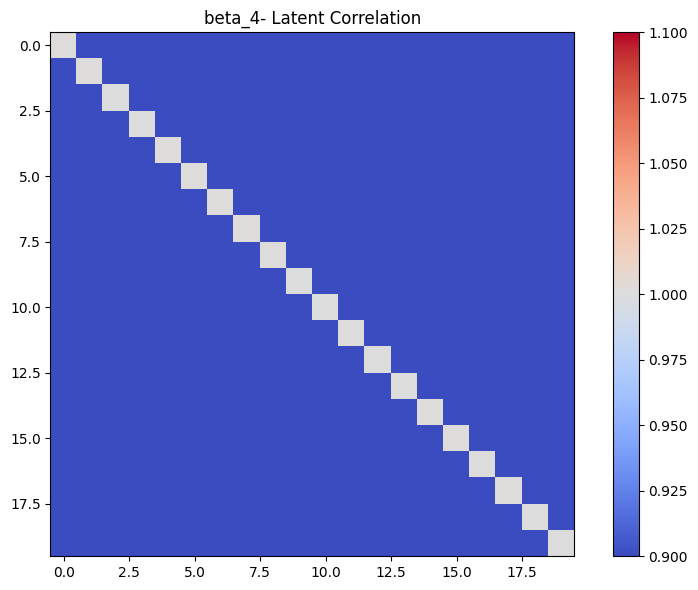


beta_7
Active dimensions (var > 0.1): 3
Mean abs correlation: 0.290


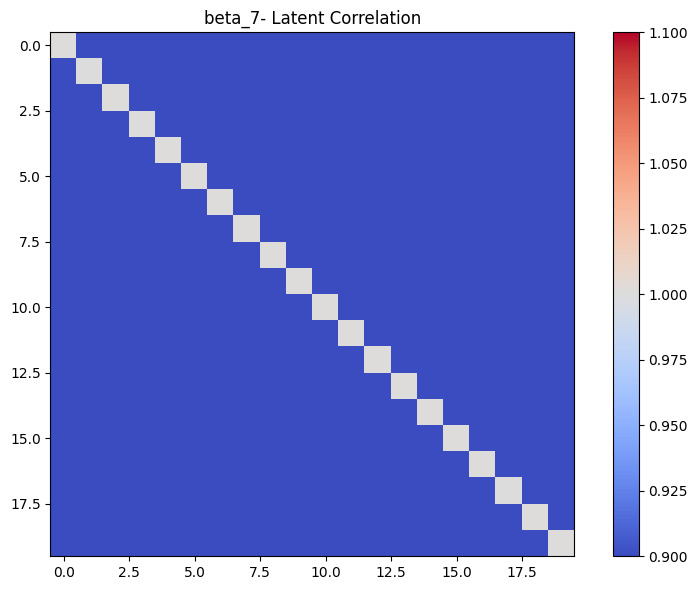


beta_10
Active dimensions (var > 0.1): 2
Mean abs correlation: 0.256


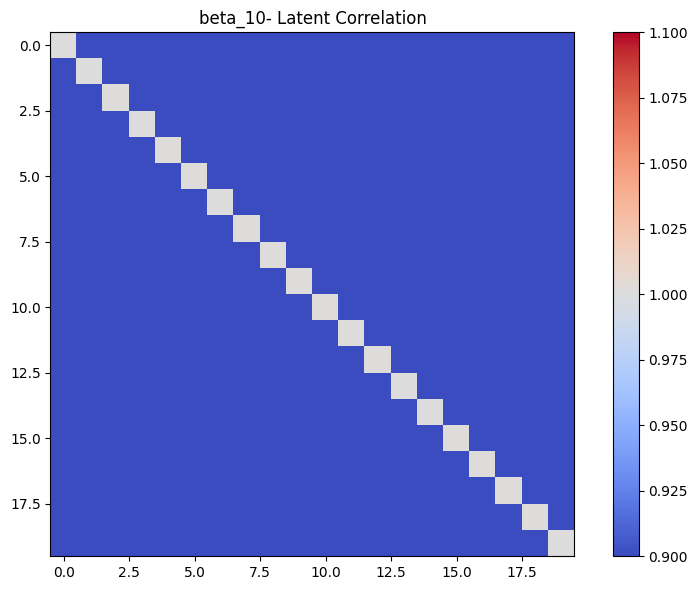


beta_15
Active dimensions (var > 0.1): 0
Mean abs correlation: nan


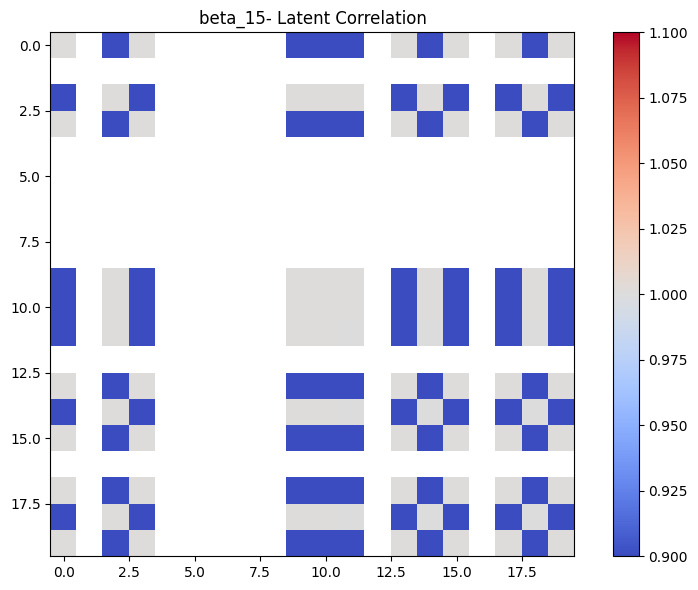

In [ ]:
for beta_name, path in models_state.items():
  model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))
  variances, corr = analyze_latent_statistics(model, train_loader)
  print(f"\n{beta_name}")
  print(f"Active dimensions (var > 0.1): {(variances > 0.1).sum().item()}")
  print(f"Mean abs correlation: {torch.abs(corr[~torch.eye(20, dtype=bool)]).mean():.3f}")

  plt.figure(figsize=(8, 6))
  plt.imshow(corr.numpy(), cmap='coolwarm', vmin=1, vmax=1)
  plt.colorbar()
  plt.title(f"{beta_name}- Latent Correlation")
  plt.tight_layout()
  plt.show()


In [ ]:
latents_values = dataset['latents_values']
latents_classes = dataset['latents_classes']

In [ ]:
indices = np.random.choice(len(images), 5000, replace=False)
sample_images = torch.tensor(images[indices], dtype=torch.float32)
sample_factors = latents_values[indices]

In [ ]:
mus = []
for model_name, path in models_state.items():
  model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))
  model.eval()
  with torch.no_grad():
    x = sample_images.view(sample_images.size(0), -1)
    x = model.encoder(x)
    mus.append(model.mu(x).cpu().numpy())

In [ ]:
from scipy.stats import spearmanr

In [ ]:
factor_names = ['color', 'shape', 'scale', 'orientation', 'posX', 'posY']

In [ ]:
corr_matrix = np.zeros((latent_dim, len(factor_names)))

/tmp/ipython-input-1013789679.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_matrix[i, j] = abs(spearmanr(mu[:, i], sample_factors[:, j])[0])


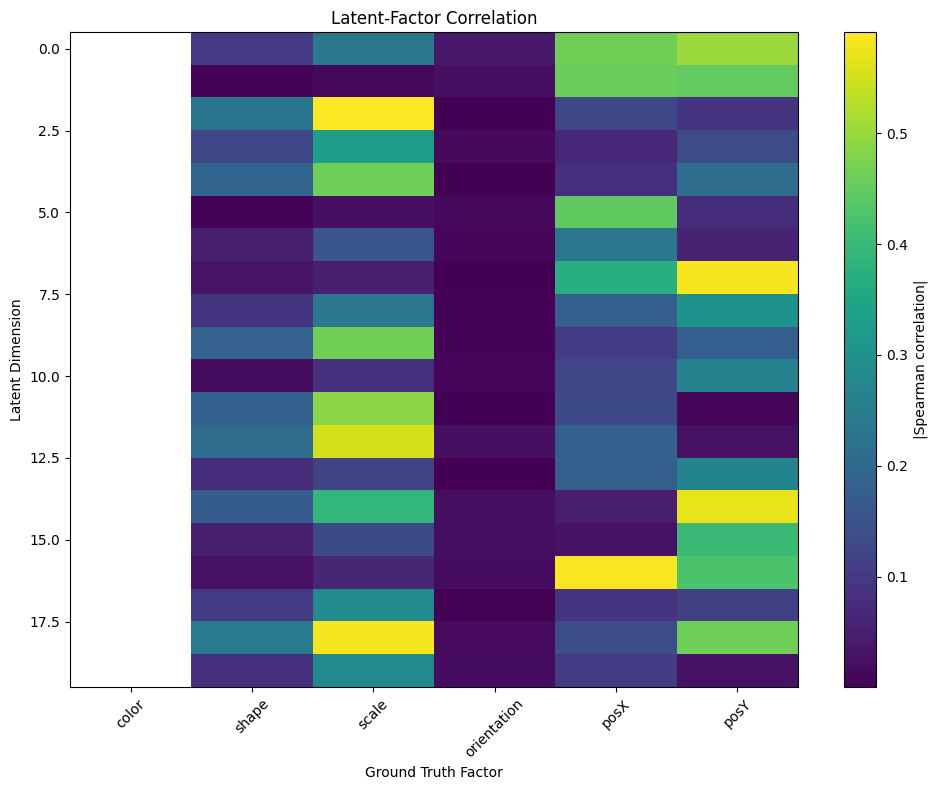

+++++++++++++++++++++++++++++++
color: latent dim 0 (corr=nan)
shape: latent dim 18 (corr=0.245)
scale: latent dim 2 (corr=0.591)
orientation: latent dim 0 (corr=0.041)
posX: latent dim 16 (corr=0.586)
posY: latent dim 7 (corr=0.583)


/tmp/ipython-input-1013789679.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_matrix[i, j] = abs(spearmanr(mu[:, i], sample_factors[:, j])[0])


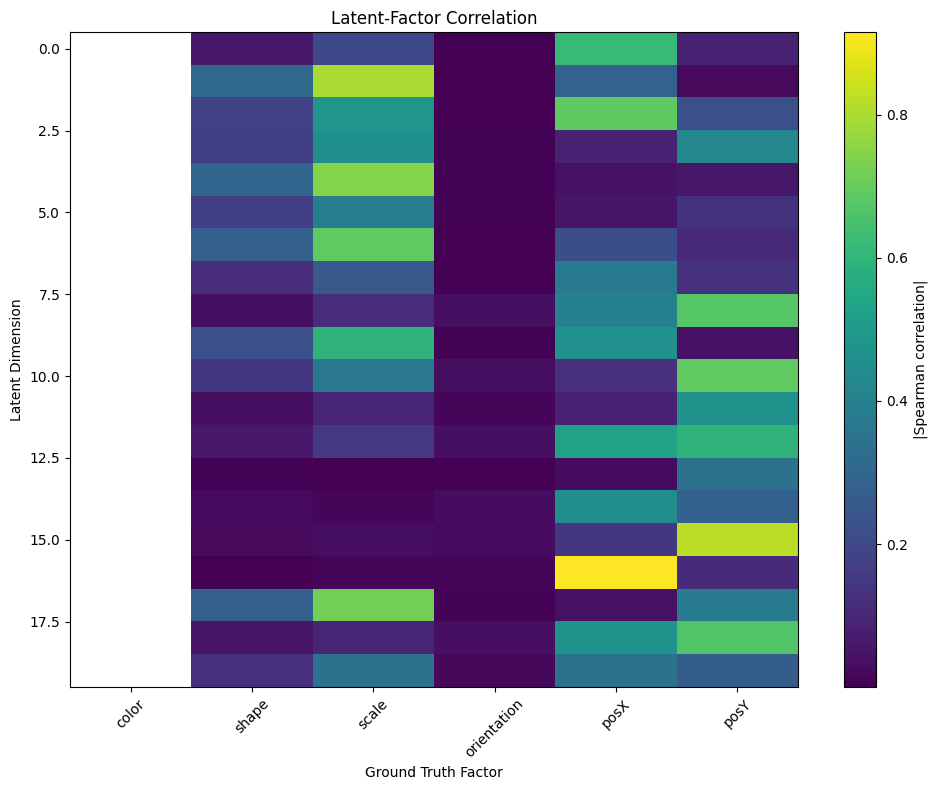

+++++++++++++++++++++++++++++++
color: latent dim 0 (corr=nan)
shape: latent dim 1 (corr=0.315)
scale: latent dim 1 (corr=0.799)
orientation: latent dim 8 (corr=0.040)
posX: latent dim 16 (corr=0.915)
posY: latent dim 15 (corr=0.819)


/tmp/ipython-input-1013789679.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_matrix[i, j] = abs(spearmanr(mu[:, i], sample_factors[:, j])[0])


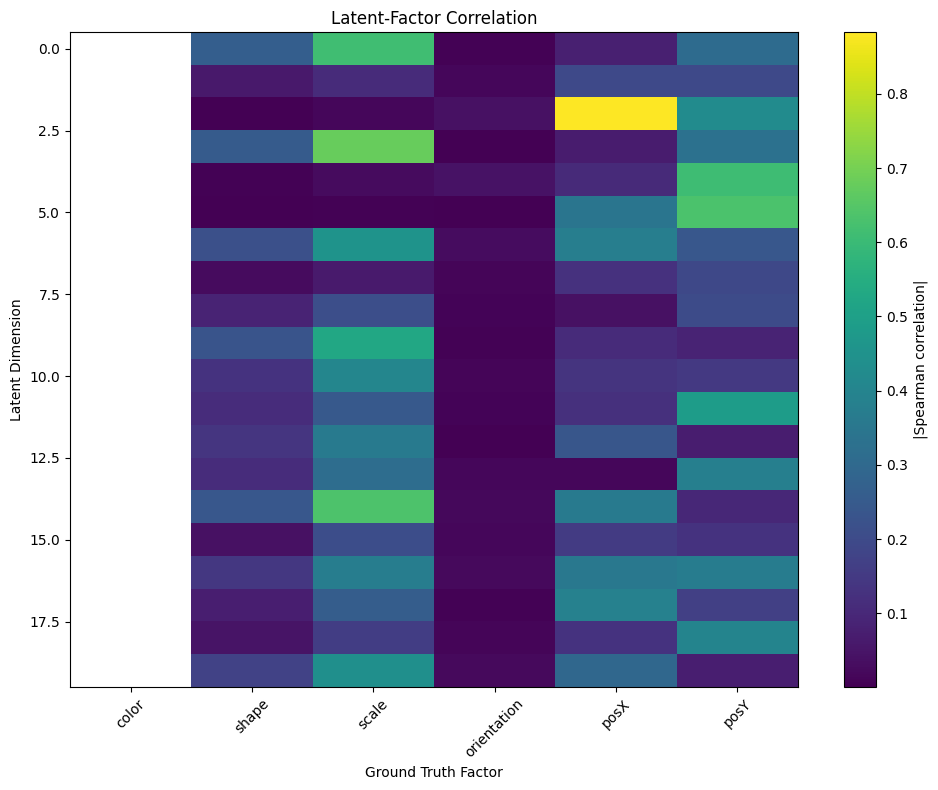

+++++++++++++++++++++++++++++++
color: latent dim 0 (corr=nan)
shape: latent dim 0 (corr=0.264)
scale: latent dim 3 (corr=0.678)
orientation: latent dim 4 (corr=0.043)
posX: latent dim 2 (corr=0.883)
posY: latent dim 5 (corr=0.633)


/tmp/ipython-input-1013789679.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_matrix[i, j] = abs(spearmanr(mu[:, i], sample_factors[:, j])[0])


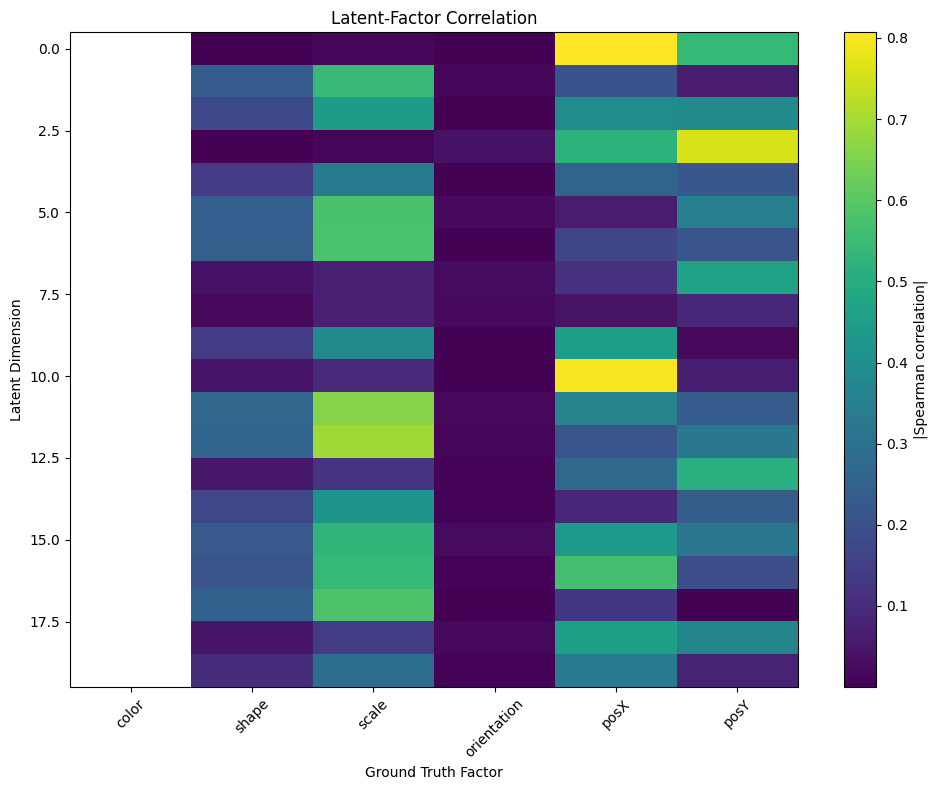

+++++++++++++++++++++++++++++++
color: latent dim 0 (corr=nan)
shape: latent dim 11 (corr=0.268)
scale: latent dim 12 (corr=0.692)
orientation: latent dim 3 (corr=0.040)
posX: latent dim 0 (corr=0.807)
posY: latent dim 3 (corr=0.758)


/tmp/ipython-input-1013789679.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_matrix[i, j] = abs(spearmanr(mu[:, i], sample_factors[:, j])[0])


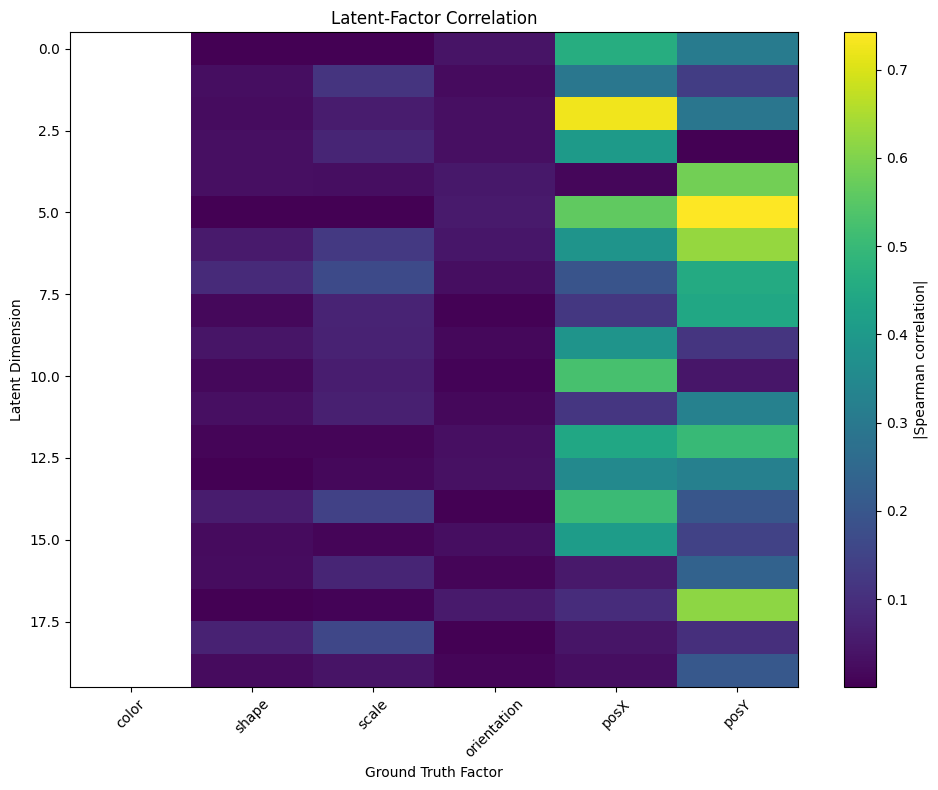

+++++++++++++++++++++++++++++++
color: latent dim 0 (corr=nan)
shape: latent dim 7 (corr=0.090)
scale: latent dim 7 (corr=0.167)
orientation: latent dim 5 (corr=0.054)
posX: latent dim 2 (corr=0.727)
posY: latent dim 5 (corr=0.742)


/tmp/ipython-input-1013789679.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_matrix[i, j] = abs(spearmanr(mu[:, i], sample_factors[:, j])[0])


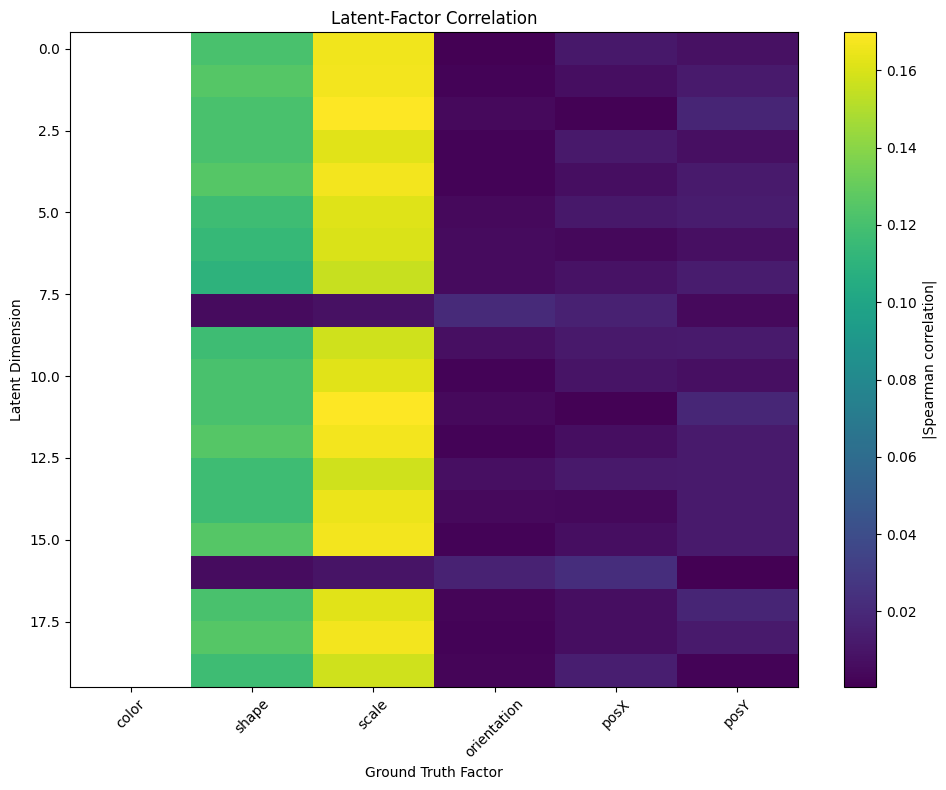

+++++++++++++++++++++++++++++++
color: latent dim 0 (corr=nan)
shape: latent dim 12 (corr=0.125)
scale: latent dim 11 (corr=0.170)
orientation: latent dim 8 (corr=0.021)
posX: latent dim 16 (corr=0.022)
posY: latent dim 11 (corr=0.018)


In [ ]:
for mu in mus:
  for i in range(latent_dim):
    for j in range(len(factor_names)):
      corr_matrix[i, j] = abs(spearmanr(mu[:, i], sample_factors[:, j])[0])
  plt.figure(figsize=(10, 8))
  plt.imshow(corr_matrix, cmap='viridis', aspect='auto')
  plt.colorbar(label='|Spearman correlation|')
  plt.xlabel('Ground Truth Factor')
  plt.ylabel('Latent Dimension')
  plt.xticks(range(len(factor_names)), factor_names, rotation=45)
  plt.title('Latent-Factor Correlation')
  plt.tight_layout()
  plt.show()

  print('+++++++++++++++++++++++++++++++')
  for j, name in enumerate(factor_names):
    best_dim = np.argmax(corr_matrix[:, j])
    print(f"{name}: latent dim {best_dim} (corr={corr_matrix[best_dim, j]:.3f})")


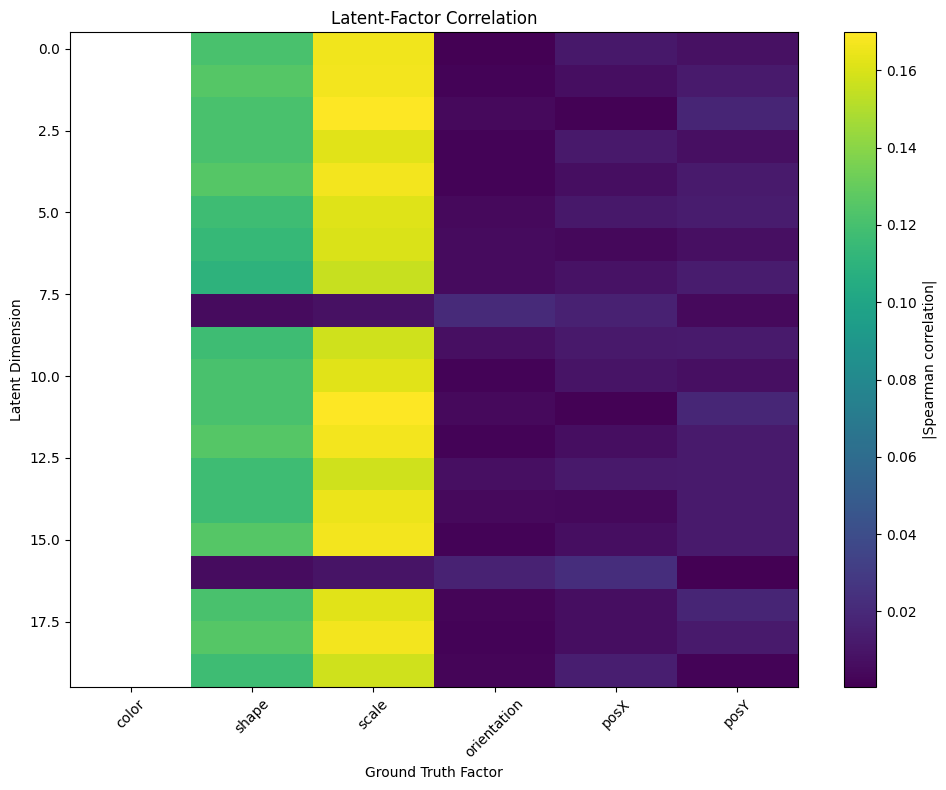

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='|Spearman correlation|')
plt.xlabel('Ground Truth Factor')
plt.ylabel('Latent Dimension')
plt.xticks(range(len(factor_names)), factor_names, rotation=45)
plt.title('Latent-Factor Correlation')
plt.tight_layout()
plt.show()